# **Experiment Notebook**



---
## Setup Environment

In [ ]:
# DO NOT MODIFY THE CODE IN THIS CELL
!pip install -q utstd

from utstd.folders import *
from utstd.ipyrenders import *

at = AtFolder(
    course_code=36106,
    assignment="AT2",
)
at.run()

import warnings
warnings.simplefilter(action='ignore')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 39.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 18.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
umap-learn 0.5.9.post2 requires scikit-learn>=1.6, but you have scikit-learn 1.5.2 which is incompatible.
Mounted at /content/gdrive

You can now save your data files in: /content/gdrive/MyDrive/36106/assignment/AT2/data


---
## Student Information


In [ ]:
# <Student to fill this section and then remove this comment>
student_name = "Nonthawat Praisompong"
student_id = "25233750"

In [ ]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h1", key='student_name', value=student_name)

In [ ]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h1", key='student_id', value=student_id)

---
## 0. Python Packages

### 0.a Install Additional Packages

> If you are using additional packages, you need to install them here using the command: `! pip install <package_name>`

### 0.b Import Packages

In [ ]:
# DO NOT MODIFY THE CODE IN THIS CELL
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import altair as alt
import scipy.stats as stats

---
## A. Project Description


In [ ]:
business_objective = """
In this project, we got the customer data, which has a credit rating as the target variable, which is a multi-class variable.
To take advantage of this dataset and outstanding competitor, we want to build a model that precisely predicts credit rating (poor/standard/good) for each customer to prevent financial loss.
This prediction will help the financial company to classify customer groups, which helps to personalise the loan strategy, marketing campaign toward the target customer.
Adjusting hyperparameters, Kfold, and SearchCV will be applied to optimise (accuracy and F1-score) our models to find a consistent parameter.
For the evaluation, we set the evaluation criteria at approximately 65% to 75% on the test set (I consider this a consistency because sometimes maximizing them always causes unexpected issues).
We realise that the highest score is important. However, we want to develop our model to generalize well on unseen data, and we consider that consistency is the key.
In summary, we want to create a model that accurately predicts credit ratings that the company will utilise to personalise their loan strategy to minimise financial loss.
On top of that, we will provide the feature important list from tree base model for consider what is the feature that they have to considered.
"""

In [ ]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='business_objective', value=business_objective)

---
## B. Dataset Understanding (Global Interpretation)

In [ ]:
folder_path = '/content/gdrive/MyDrive/36106/assignment/AT2/data'

In [ ]:
# DO NOT MODIFY THE CODE IN THIS CELL
try:
  df = pd.read_csv(at.folder_path / "credit_rating.csv")
except Exception as e:
  print(e)

In [ ]:
pd.options.display.max_columns = None
df.head()

,customer_id,prefix,full_name,gender,dob,age,birth_country,email,phone_number,secondary_address,building_number,street_name,street_suffix,city,postcode,state_abbr,occupation,annual_income,count_bank_accounts,count_credit_cards,cc_number,cc_expiry,cc_security_code,cc_interest_rate,loans_count,avg_days_past_due,count_delayed_payment,credit_limit_change,count_credit_inquiries,credit_mix,outstanding_debt,credit_ratio,count_credit_history_years,min_amount_payment,monthly_emi_payment,_monthly_invested_amount,payment_behaviour,monthly_balance,last_9_loan_type,last_8_loan_type,last_7_loan_type,last_6_loan_type,last_5_loan_type,last_4_loan_type,last_3_loan_type,last_2_loan_type,last_1_loan_type,credit_rating
0,5bd44cee-f2d0-457f-9b79-1fdd894da18c,Mr.,Kevin Moon,m,1993-12-06,31,AU,kimberlypark@example.org,(08)35431944,Unit 93,0,April Amble,Brow,Chaneyborough,8442,QLD,Journalist,22229.060,6,4,2271879300837817,11/31,104,5.0,3,10,10,9.44,9,Standard,1396.14,33.061861,156,Yes,52.138474,44.084010,High_spent_Medium_value_payments,321.019683,No Loan,No Loan,No Loan,No Loan,No Loan,No Loan,Debt Consolidation Loan,Home Equity Loan,Debt Consolidation Loan,Standard
1,9cb378bd-57f0-4613-a987-b95bbdb84f8f,Dr.,Matthew May-Lewis,m,1981-10-21,43,NZ,garciathomas@example.net,0485 357 742,Level 2,43,Davis Crest,Rest,Andrewborough,2652,TAS,Musician,17060.705,8,3,349101291688485,09/30,661,11.0,4,24,8,9.64,2,Standard,268.81,36.377621,269,Yes,51.934634,39.628311,Low_spent_Small_value_payments,327.009597,No Loan,No Loan,No Loan,No Loan,No Loan,Debt Consolidation Loan,Home Equity Loan,Auto Loan,Auto Loan,Standard
2,0e0b24e2-74d7-48f1-9b45-e6cfbf79dbff,Dr.,Donald Sanchez,m,2001-06-15,24,AU,qlee@example.org,20356212,937/,96,Emily Little,Drive,New Chadbury,2955,NSW,Accountant,34428.210,2,4,4634389038551183,08/30,977,8.0,0,3,12,8.51,0,Good,180.70,39.917508,326,No,0.000000,84.774645,High_spent_Small_value_payments,432.727105,No Loan,No Loan,No Loan,No Loan,No Loan,No Loan,No Loan,No Loan,No Loan,Good
3,d45b3167-77e6-4b2a-96f3-a9bf2ee07621,Mr.,Jonathan Thornton,m,2004-01-23,21,AU,cmorgan@example.com,0627-6253,Level 3,5,William Pathway,Circle,Elliottside,2381,WA,Accountant,12613.920,4,6,30359329057818,08/34,729,13.0,3,14,17,17.51,3,Standard,569.11,39.841494,376,Yes,16.941903,41.943603,Low_spent_Medium_value_payments,346.630494,No Loan,No Loan,No Loan,No Loan,No Loan,No Loan,Personal Loan,Student Loan,Home Equity Loan,Standard
4,79a17520-248e-4bea-92b8-22c78d968172,Mr.,Yasmin Agarwal,m,1993-11-14,31,IN,xtodd@example.com,9957-3583,00/,5,Martin Close,Part,Gonzalezberg,3048,TAS,Journalist,34775.160,7,9,375257503725320,05/33,202,25.0,5,20,20,17.16,6,Bad,3003.45,36.058472,162,Yes,126.596814,67.970377,High_spent_Medium_value_payments,360.325808,No Loan,No Loan,No Loan,No Loan,Auto Loan,Mortgage Loan,Auto Loan,Payday Loan,Not Specified,Poor


In [ ]:
# Checking dimension
df.shape

(12500, 48)

In [ ]:
# Statistic for numerical columns
df.describe().round(2)

# min customer age = 14 is wrong which should be 18
# min of count_bank_accounts = 0 must be inccorect value.
# min of avg_days_past_due =  - 5  is weird (incorrect)
# min of monthly_emi_payment less than 0 is incorrect values.
# count_credit_history_years is representing in month instead of year (require engineering)

,age,building_number,postcode,annual_income,count_bank_accounts,count_credit_cards,cc_number,cc_security_code,cc_interest_rate,loans_count,avg_days_past_due,count_delayed_payment,credit_limit_change,count_credit_inquiries,outstanding_debt,credit_ratio,count_credit_history_years,monthly_emi_payment,_monthly_invested_amount,monthly_balance
count,12500.00,12500.00,12500.00,12500.00,12500.00,12500.00,1.250000e+04,12500.00,12500.00,12500.00,12500.00,12500.00,12500.00,12500.00,12500.00,12500.00,12500.00,12500.00,12500.00,12500.00
mean,33.31,180.57,3168.21,50505.12,5.37,5.53,3.750285e+17,879.49,14.53,3.53,21.07,13.34,10.39,5.76,1426.22,32.29,221.16,88.19,194.13,403.65
std,10.77,277.26,1811.34,38300.76,2.59,2.07,1.242247e+18,1536.07,8.74,2.45,14.87,6.27,6.77,3.83,1155.17,5.12,99.70,83.26,195.34,215.01
min,14.00,0.00,200.00,7005.93,0.00,0.00,6.040204e+10,0.00,1.00,0.00,-5.00,0.00,-6.31,0.00,0.23,20.88,2.00,-1.00,0.00,0.42
25%,24.00,6.00,2602.00,19342.97,3.00,4.00,3.896755e+13,266.00,7.00,2.00,10.00,9.00,5.34,3.00,566.07,28.01,144.75,25.56,73.87,269.76
50%,33.00,42.50,2694.00,36999.70,5.00,5.00,3.515906e+15,542.00,13.00,3.00,18.00,14.00,9.38,5.00,1166.16,32.36,219.00,61.51,128.94,337.60
75%,42.00,232.00,2968.00,71683.47,7.00,7.00,4.690149e+15,814.00,20.00,5.00,28.00,18.00,14.85,8.00,1945.96,36.50,302.00,131.39,233.36,469.96
max,56.00,999.00,9996.00,179987.28,11.00,11.00,4.999833e+18,9992.00,34.00,9.00,67.00,28.00,36.97,17.00,4998.07,48.18,404.00,357.41,1885.65,1528.89


In [ ]:
# Statistic for categorical columns
df.describe(include = 'object').round(2)

# most of the loan type is No Loan
# most of customer's credit_rating = Standard

,customer_id,prefix,full_name,gender,dob,birth_country,email,phone_number,secondary_address,street_name,street_suffix,city,state_abbr,occupation,cc_expiry,credit_mix,min_amount_payment,payment_behaviour,last_9_loan_type,last_8_loan_type,last_7_loan_type,last_6_loan_type,last_5_loan_type,last_4_loan_type,last_3_loan_type,last_2_loan_type,last_1_loan_type,credit_rating
count,12500,12500,12500,12500,12500,12500,12500,12500,12500,12500,12500,12500,12500,12500,12500,12500,12500,12500,12500,12500,12500,12500,12500,12500,12500,12500,12500,12500
unique,12500,5,11614,2,8380,13,12169,12500,2659,11712,200,9369,8,15,121,3,2,6,10,10,10,10,10,10,10,10,10,3
top,2ea6eabf-d428-4fc5-927c-811bc37b814c,Mr.,Jennifer Smith,f,1992-01-01,AU,ssmith@example.org,+61231581991,Level 3,Robert Mew,Lookout,West Michael,VIC,Lawyer,10/34,Standard,Yes,Low_spent_Small_value_payments,No Loan,No Loan,No Loan,No Loan,No Loan,No Loan,No Loan,No Loan,No Loan,Standard
freq,1,4387,11,6262,7,10903,4,1,180,5,85,14,1638,887,133,5731,7429,4556,12018,11601,10641,9623,8682,6750,4781,2817,1426,6618


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12500 entries, 0 to 12499
Data columns (total 48 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   customer_id                 12500 non-null  object 
 1   prefix                      12500 non-null  object 
 2   full_name                   12500 non-null  object 
 3   gender                      12500 non-null  object 
 4   dob                         12500 non-null  object 
 5   age                         12500 non-null  int64  
 6   birth_country               12500 non-null  object 
 7   email                       12500 non-null  object 
 8   phone_number                12500 non-null  object 
 9   secondary_address           12500 non-null  object 
 10  building_number             12500 non-null  int64  
 11  street_name                 12500 non-null  object 
 12  street_suffix               12500 non-null  object 
 13  city                        125

In [ ]:
# Checking dtype
df.dtypes.value_counts().to_frame('How many features')

,How many features
object,28
int64,12
float64,8


In [ ]:
## Checking the missing values?
print(df.isnull().sum()[lambda x: x > 0].to_frame('The number of the missing values'))  # no missing values

Empty DataFrame
Columns: [The number of the missing values]
Index: []


In [ ]:
# Checking the duplicate value in this dataset.
duplicate_rows = df[df.duplicated()]
duplicate_rows  # no duplicate rows

,customer_id,prefix,full_name,gender,dob,age,birth_country,email,phone_number,secondary_address,building_number,street_name,street_suffix,city,postcode,state_abbr,occupation,annual_income,count_bank_accounts,count_credit_cards,cc_number,cc_expiry,cc_security_code,cc_interest_rate,loans_count,avg_days_past_due,count_delayed_payment,credit_limit_change,count_credit_inquiries,credit_mix,outstanding_debt,credit_ratio,count_credit_history_years,min_amount_payment,monthly_emi_payment,_monthly_invested_amount,payment_behaviour,monthly_balance,last_9_loan_type,last_8_loan_type,last_7_loan_type,last_6_loan_type,last_5_loan_type,last_4_loan_type,last_3_loan_type,last_2_loan_type,last_1_loan_type,credit_rating


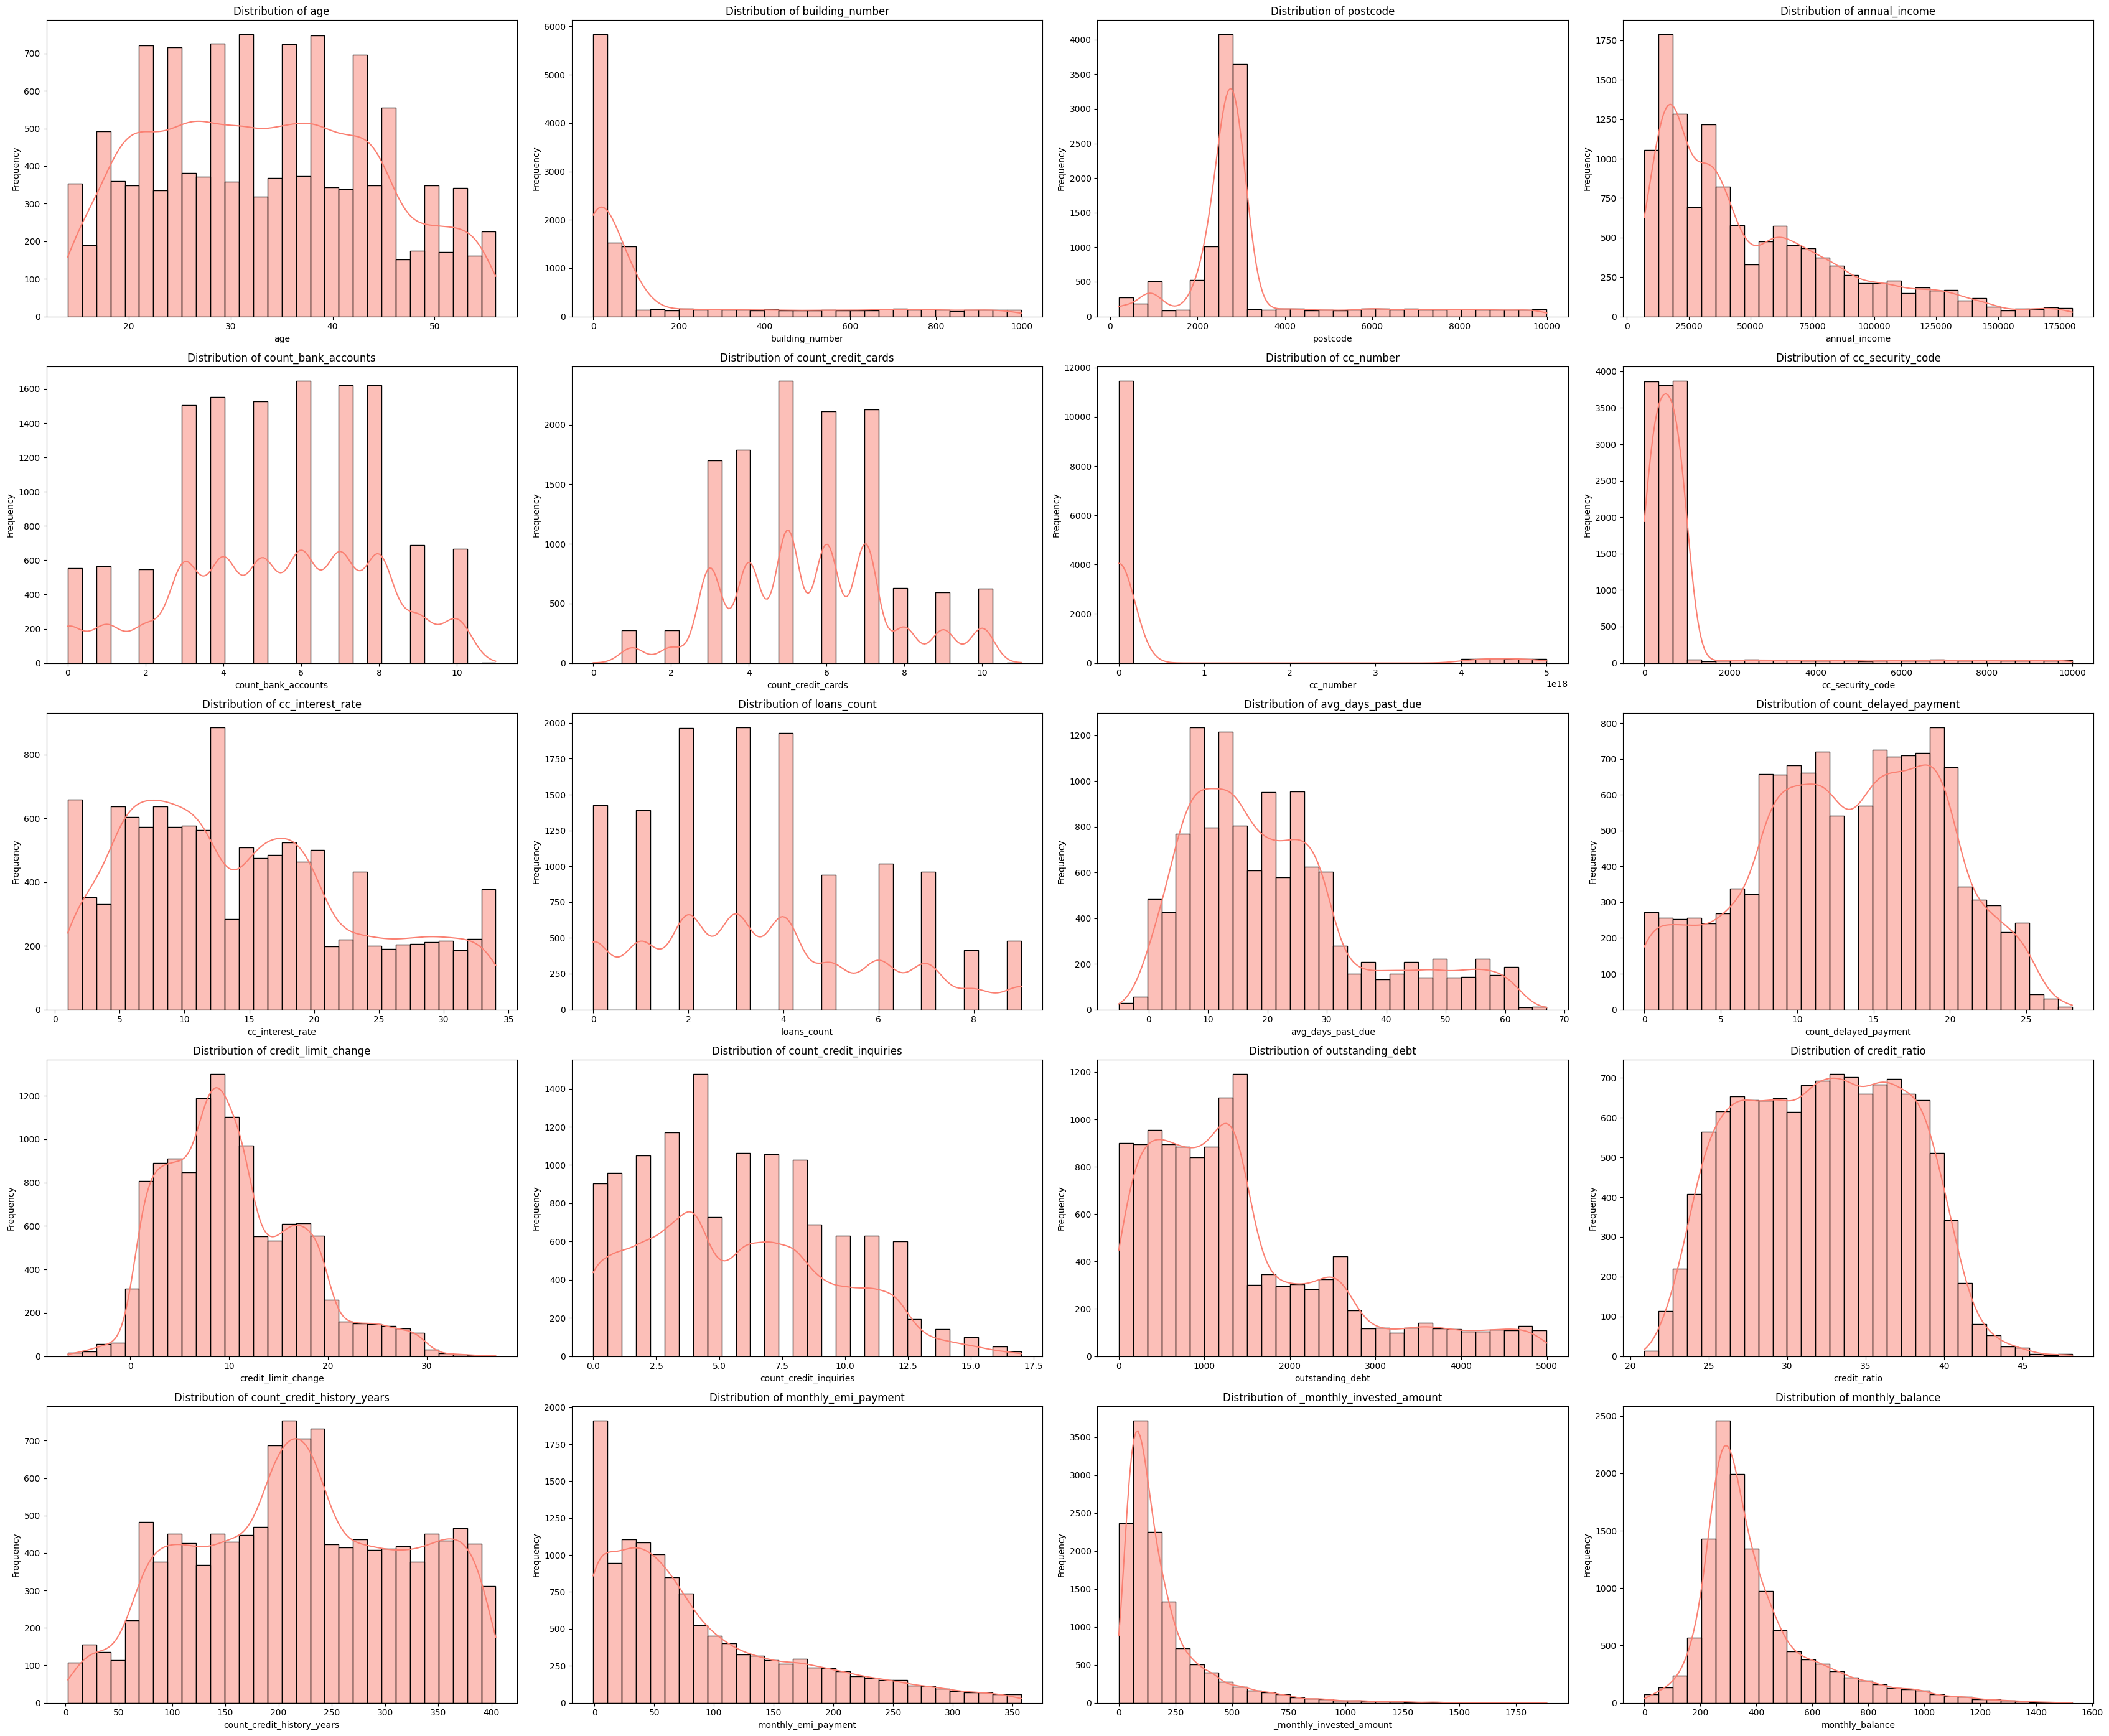

In [ ]:
# Distribution chart for numeric columns
numeric_df = df.select_dtypes('number')
fig, axes = plt.subplots(5, 4, figsize=(34, 28))
axes = axes.flatten()

for i, var in enumerate(numeric_df):
    sns.histplot(df[var], kde=True, bins=30, ax=axes[i], color='salmon')
    axes[i].set_title(f'Distribution of {var}')
    axes[i].set_xlabel(var)
    axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

# Annual income have right skew distribution indicating most customer do not have high income.
# Credit card count are heavily lie between 3 to 6
# 2 - 3 are the numbers that the customer make a loan count following wiht 1 and 0.
# avg_days_past_due are beween 1 month (majority)

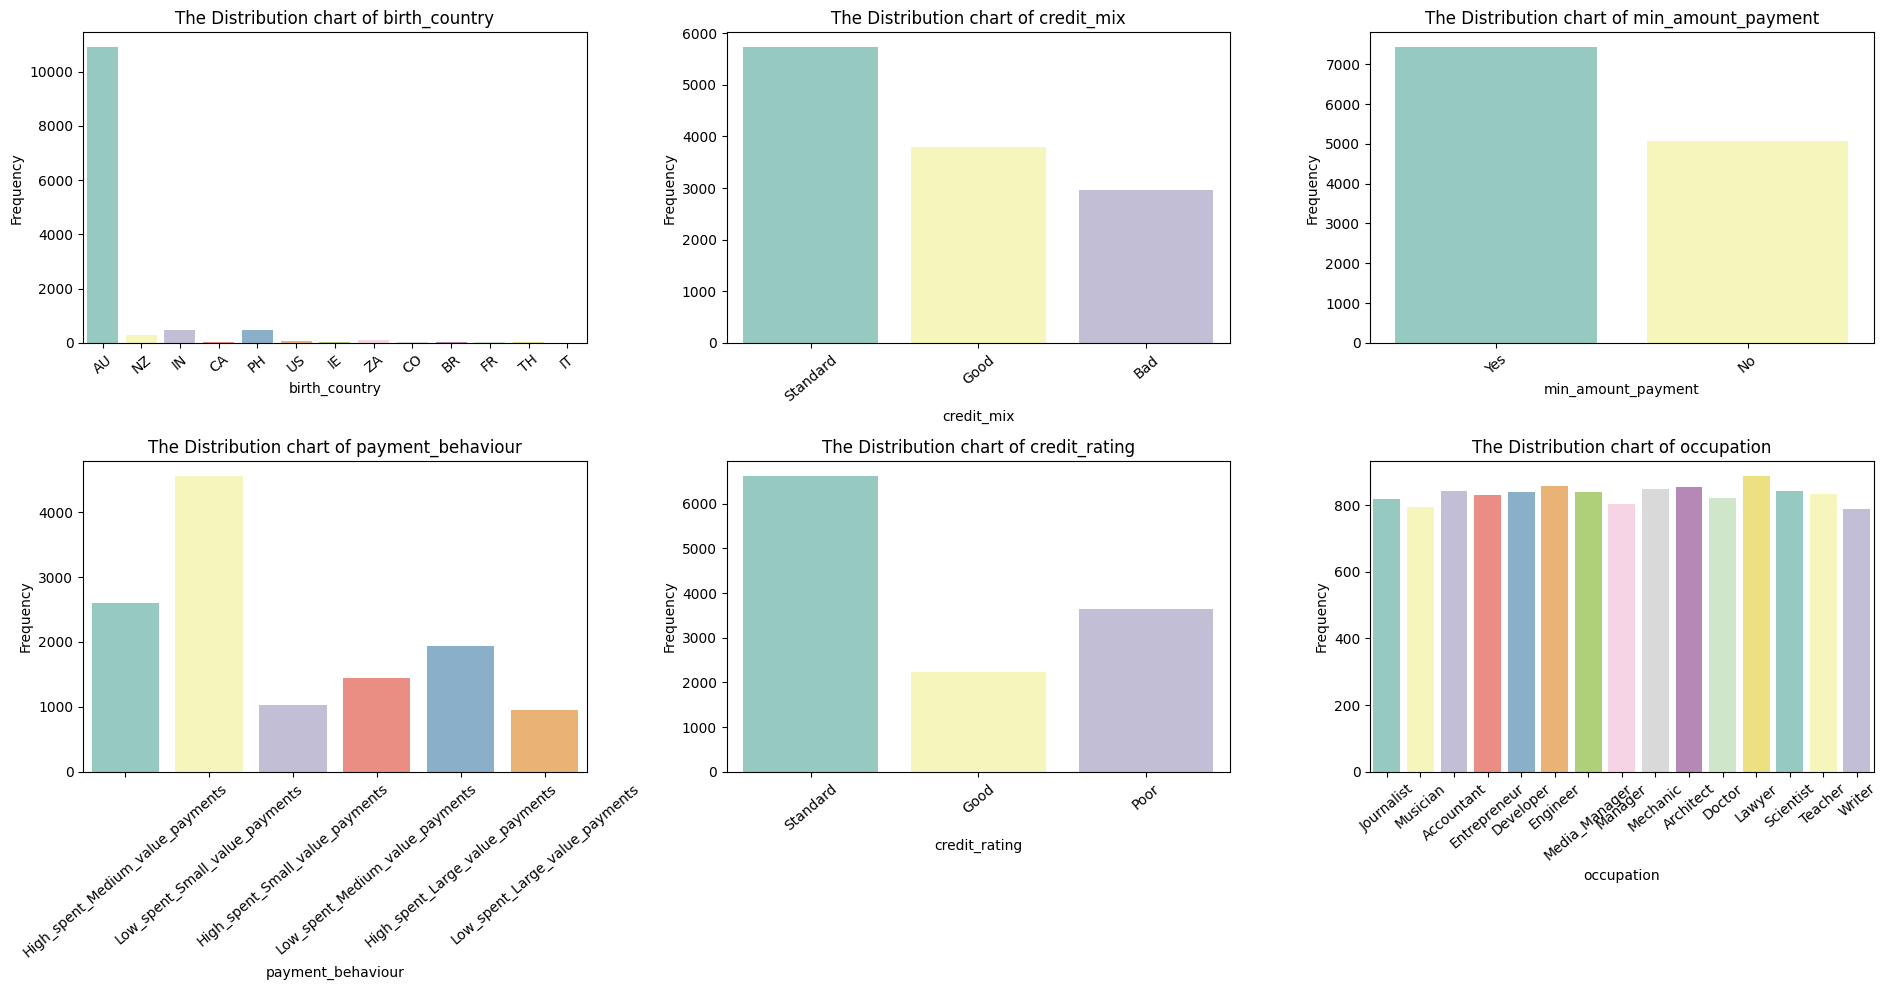

In [ ]:
# Distribution for category columns

category_cols = df[['birth_country', 'credit_mix', 'min_amount_payment', 'payment_behaviour', 'credit_rating', 'occupation']]

fig, axes = plt.subplots(2, 3, figsize=(19, 10))
axes = axes.flatten()

for i, var in enumerate(category_cols):
    sns.countplot(data = df, x = var, ax = axes[i], palette = 'Set3')
    axes[i].set_title(f'The Distribution chart of {var}')
    axes[i].set_xlabel(var)
    axes[i].set_ylabel('Frequency')
    axes[i].tick_params(axis = 'x', rotation = 40)

plt.tight_layout()
plt.show()

# Most customers were born in Australia (using this feature in modelling will create bias)
# credit_mix: standard have the highest count following good and bad
# min_amount_payment: yes is the most frequent indicate money stress (bad sign for lower credit score)
# Most customers have low spend count with a small value on their payment

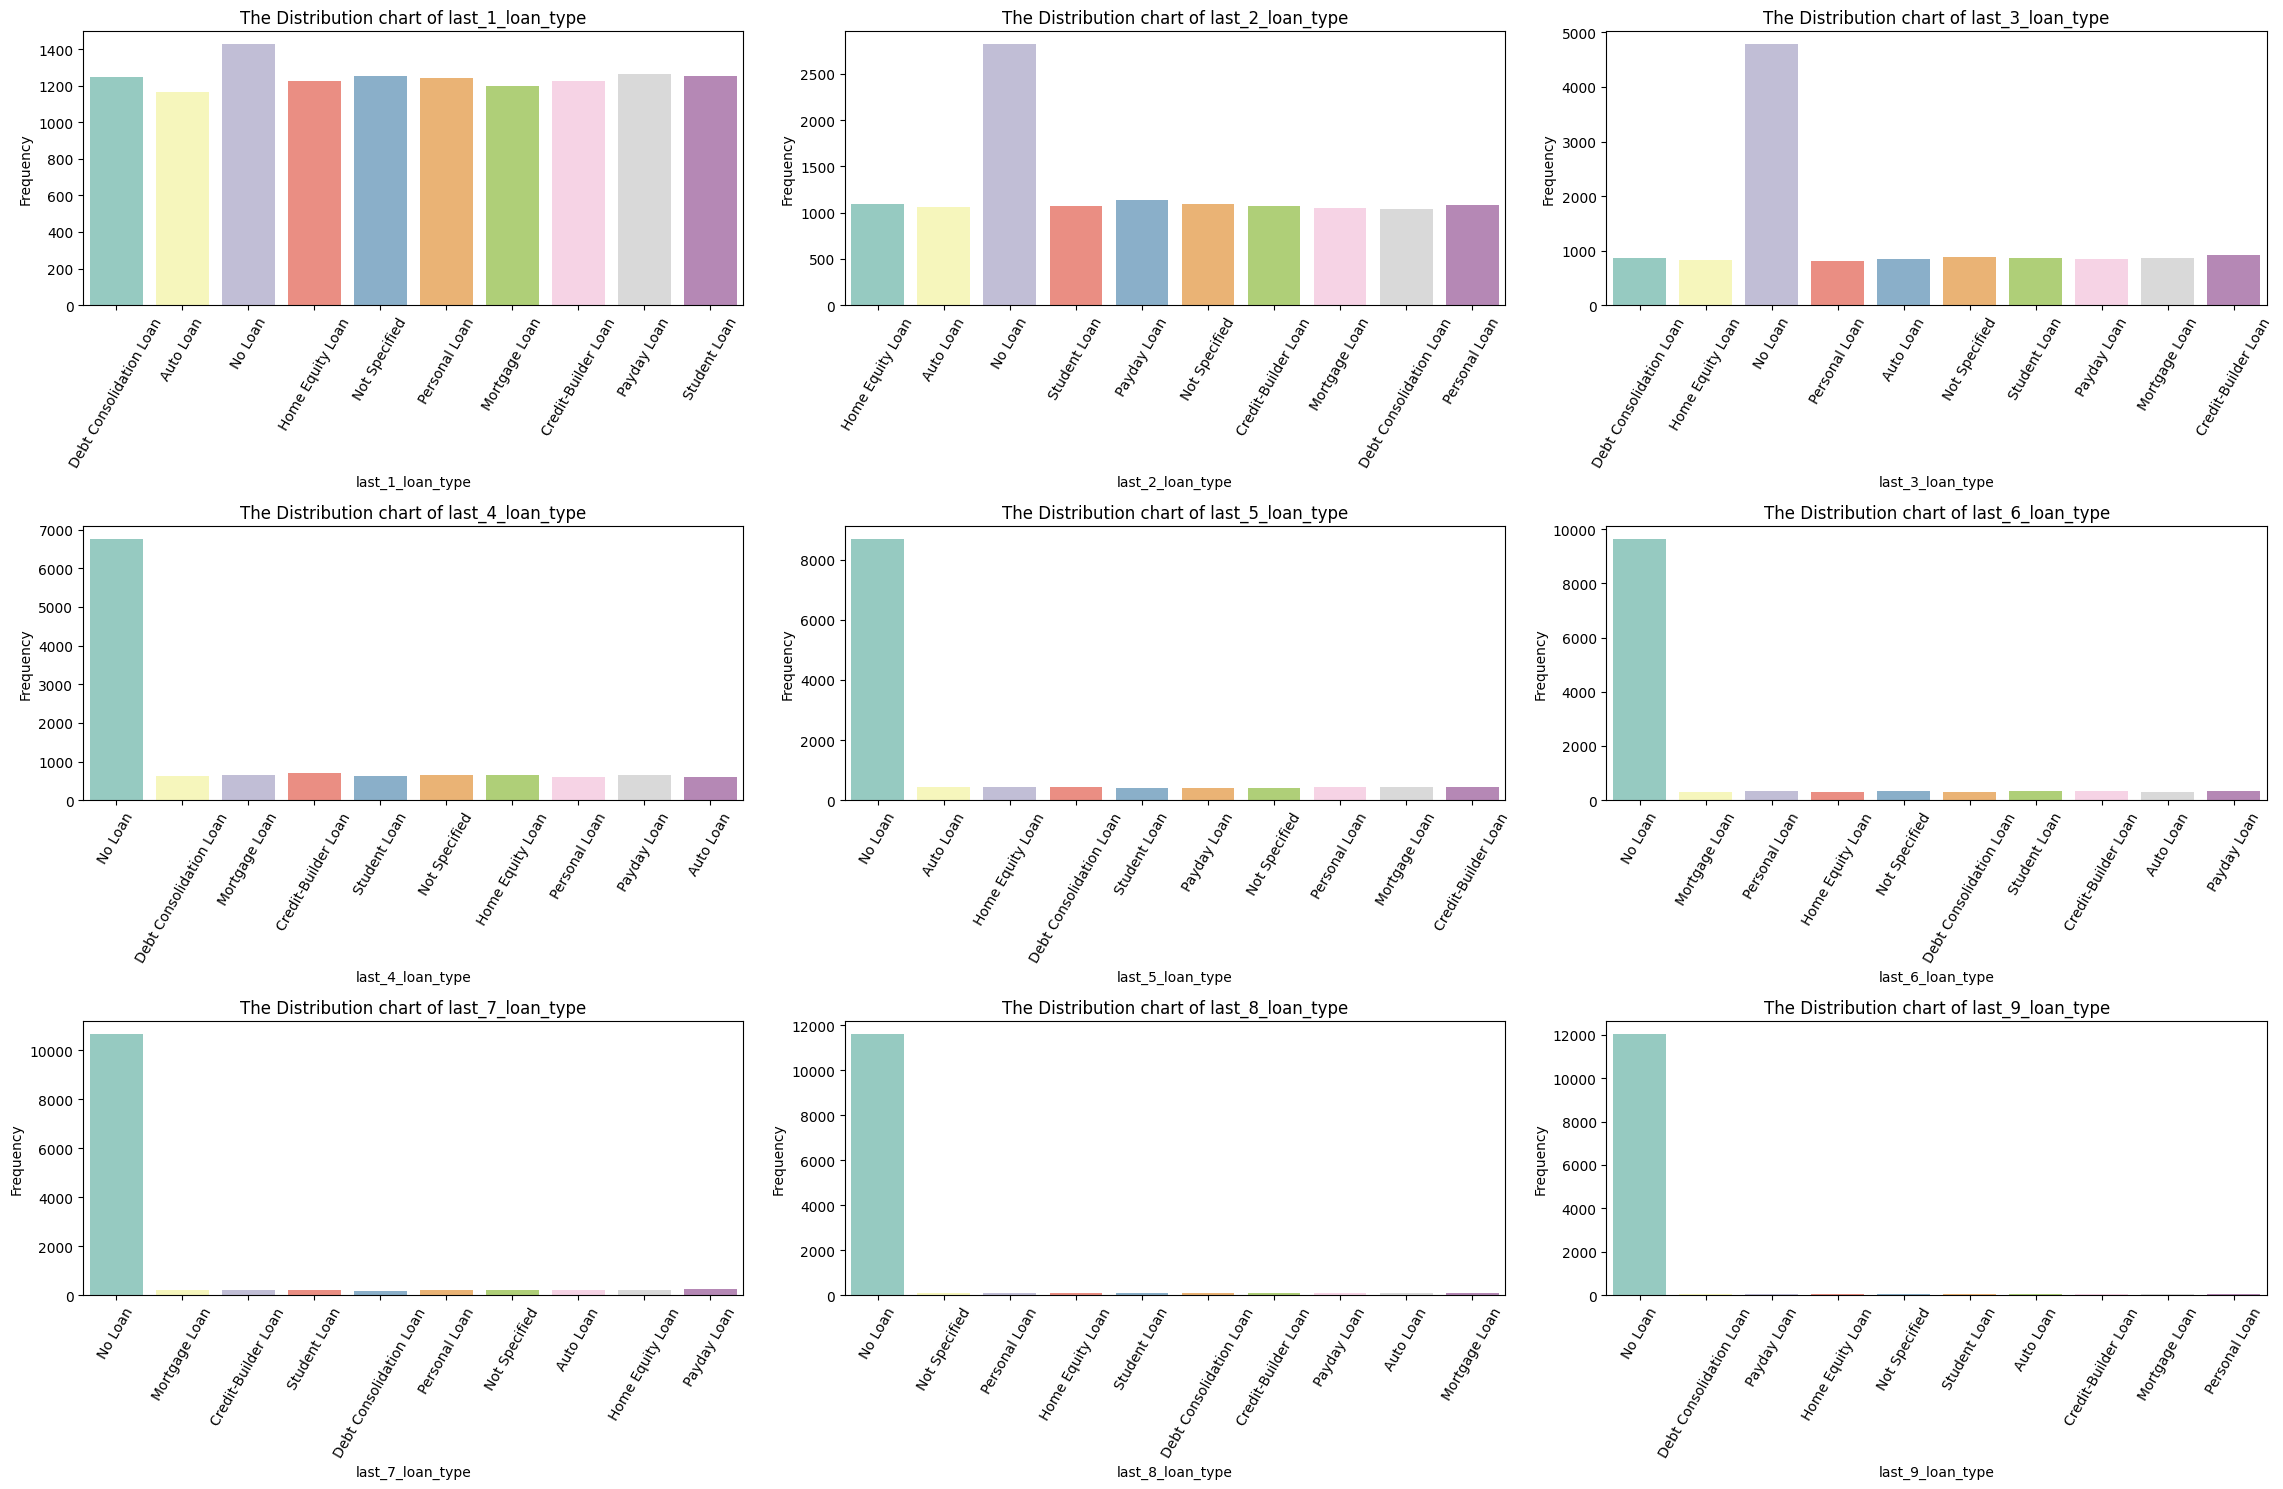

In [ ]:
# Distribution for category loan type columns

category_cols = df[['last_1_loan_type', 'last_2_loan_type', 'last_3_loan_type', 'last_4_loan_type', 'last_5_loan_type', 'last_6_loan_type', 'last_7_loan_type', 'last_8_loan_type', 'last_9_loan_type']]

fig, axes = plt.subplots(3, 3, figsize=(23, 15))
axes = axes.flatten()

for i, var in enumerate(category_cols):
    sns.countplot(data = df, x = var, ax = axes[i], palette = 'Set3')
    axes[i].set_title(f'The Distribution chart of {var}')
    axes[i].set_xlabel(var)
    axes[i].set_ylabel('Frequency')
    axes[i].tick_params(axis = 'x', rotation = 60)

plt.tight_layout()
plt.show()

# Only last_1_loan_type to 3 have a distribution on loan type which No loan have the highest count espescially on 2 and 3_loan_type.
# However, 4 to 9_loan_type did not have significant and will crete noise and bias due to imbalance of dataset.
# Then, we will do OHE for last_1_loan_type to 3 and drop the rest.

---
## C. Feature Understanding (Local Interpretation)

### C.1 Explore Target Variable

> Save the name of column used as the target variable and call it `target_name`

In this project, credit rating is a multi-label variable indicating the likelihood of customers paying back on time. By exploring the target variable helpe us to observe the distribution that indicate the imbalance of the datase which might create bias on the result.

In [ ]:
target_name = df['credit_rating']

credit_rating
Standard    6618
Poor        3646
Good        2236
Name: count, dtype: int64





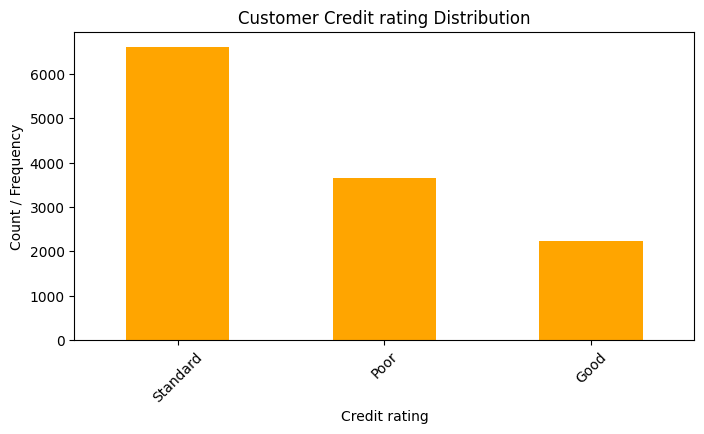

In [ ]:
# The distribution of unique values
dis = target_name.value_counts()
print(dis)
print('\n\n')

# Distribution chart
plt.figure(figsize=(8, 4))
dis.plot(kind= 'bar', color = 'orange')
plt.title('Customer Credit rating Distribution')
plt.xlabel('Credit rating')
plt.ylabel('Count / Frequency')
plt.xticks(rotation = 45)
plt.show()

# Standard has the highest type of customer. followed by poor.
# Stratified cross-validation might help in generalise on modellin part.

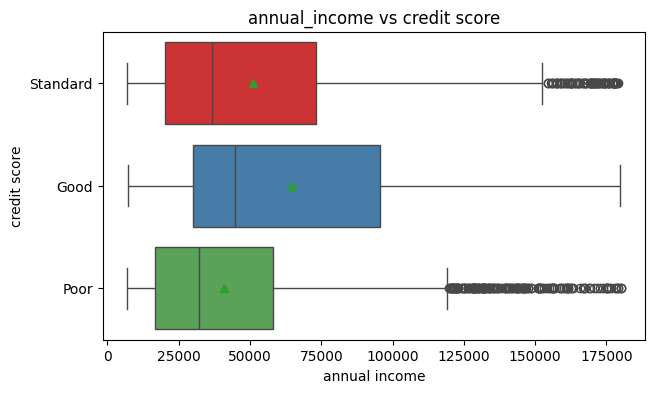

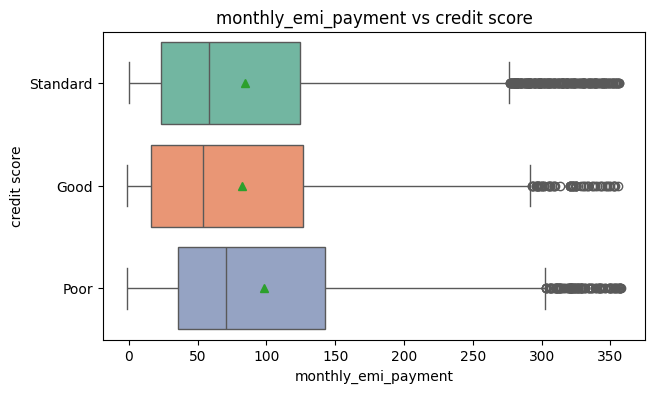

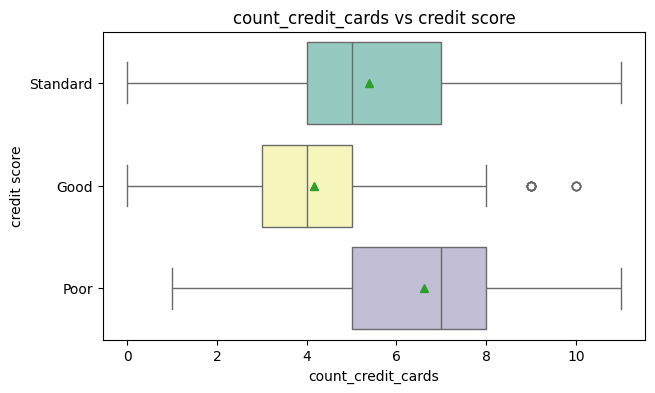

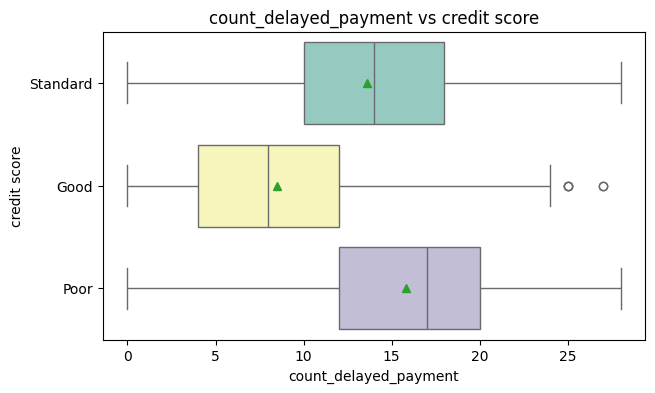

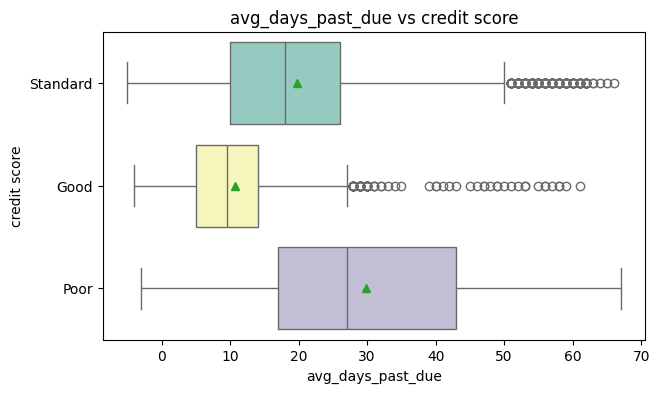

In [ ]:
 ## Box plots of each interest numeric variables VS credit score
# annual_income vs credit score
plt.figure(figsize = (7, 4))
sns.boxplot(data = df, x = 'annual_income', y = target_name, palette='Set1', showmeans = True)
plt.title('annual_income vs credit score')
plt.xlabel('annual income')
plt.ylabel('credit score')
plt.show()

# monthly_emi_payment vs credit score
plt.figure(figsize = (7, 4))
sns.boxplot(data = df, x = 'monthly_emi_payment', y = target_name, palette='Set2', showmeans = True)
plt.title('monthly_emi_payment vs credit score')
plt.xlabel('monthly_emi_payment')
plt.ylabel('credit score')
plt.show()

# count_credit_cards vs credit score
plt.figure(figsize = (7, 4))
sns.boxplot(data = df, x = 'count_credit_cards', y = target_name, palette='Set3', showmeans = True)
plt.title('count_credit_cards vs credit score')
plt.xlabel('count_credit_cards')
plt.ylabel('credit score')
plt.show()

# count_delayed_payment vs credit score
plt.figure(figsize = (7, 4))
sns.boxplot(data = df, x = 'count_delayed_payment', y = target_name, palette='Set3', showmeans = True)
plt.title('count_delayed_payment vs credit score')
plt.xlabel('count_delayed_payment')
plt.ylabel('credit score')
plt.show()

# avg_days_past_due vs credit score
plt.figure(figsize = (7, 4))
sns.boxplot(data = df, x = 'avg_days_past_due', y = target_name, palette='Set3', showmeans = True)
plt.title('avg_days_past_due vs credit score')
plt.xlabel('avg_days_past_due')
plt.ylabel('credit score')
plt.show()

# Overall, they have similar characteristics.
# Customers with a better credit score than having a  higher income
# Customers with a lower credit score pays more for the monthly payment.
# Customers with a lower credit score tend to have more credit cards.
# Customers with a lower credit score have a higher count of delayed payments, and average days past due.

In [ ]:
target_insights = """
The distribution show that the standard group is the majority group, followed by poor and good (approximately 6000, 3000, and 2000).
From my perspective, their distribution has a little imbalance in the dataset, but in practice, this is a normal situation that I consider acceptable, but requires some preparation (In this case, Stratified splitting)
Furthermore, when we compare credit_rating with other numerical variables, they gave us some interesing insight.
Customers with a better credit score than having a  higher income. Customers with a lower credit score pays more for the monthly payment, tend to have more number credit cards and higher count of delayed payments, and average days past due.
"""

In [ ]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='target_insights', value=target_insights)

### C.2 Explore Feature of Interest `\<annual_income\>`

In [ ]:
int_var1 = df['annual_income']

In [ ]:
# Descritive statistic
int_var1.describe().round(2)

# the distribution of the customer anaual income is various which using log transformation might require for the classification model.

,annual_income
count,12500.00
mean,50505.12
std,38300.76
min,7005.93
25%,19342.97
50%,36999.70
75%,71683.47
max,179987.28


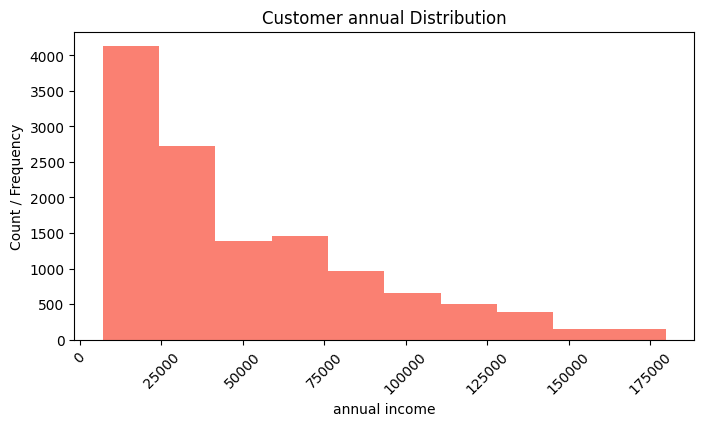

In [ ]:
# hist plot for income distribution

plt.figure(figsize=(8, 4))
int_var1.plot(kind= 'hist', color = 'salmon')
plt.title('Customer annual Distribution')
plt.xlabel('annual income')
plt.ylabel('Count / Frequency')
plt.xticks(rotation = 45)
plt.show()  # right skew distribution with outliers.

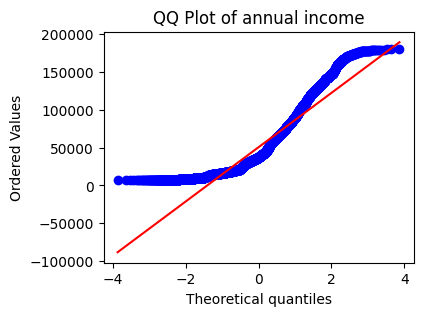

In [ ]:
### QQ plot for visualisation distribution
plt.figure(figsize=(4, 3))
stats.probplot(int_var1, dist="norm", plot=plt)
plt.title('QQ Plot of annual income')
plt.show()

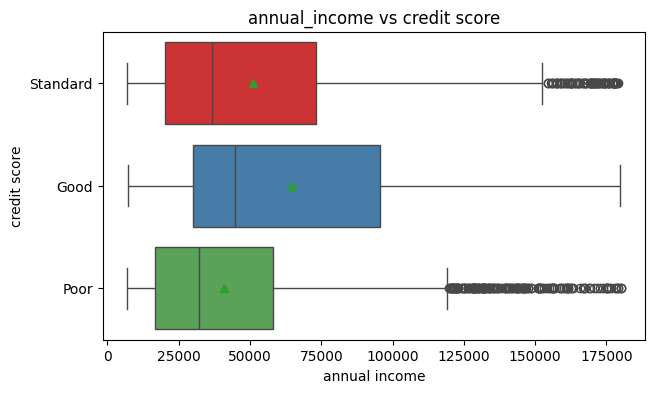

In [ ]:
# Box plot for each credit score
plt.figure(figsize = (7, 4))
sns.boxplot(data = df, x = int_var1, y = target_name, palette='Set1', showmeans = True)
plt.title('annual_income vs credit score')
plt.xlabel('annual income')
plt.ylabel('credit score')
plt.show()

# From this chart, customers with better credit score have higher income.

In [ ]:
feature_1_insights = """
Overall, annual_income has the right skew distribution with a maximum value = 179,987, indicating an outlier. their majority distribution is between 7,005 to approximately 40,000.
Indicating that most customers have lower income or lower annual income are mostly making a loan.
Interetingly, box plot show that people with the higher score tend to have higher annual income.
"""

In [ ]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='feature_1_insights', value=feature_1_insights)

### C.3 Explore Feature of Interest `\<outstanding_debt\>`


In [ ]:
int_var2 = df['outstanding_debt']

In [ ]:
# Descritive statistic
int_var2.describe().round(2)  # max value indicate oulier and might require log-transformation.

,outstanding_debt
count,12500.00
mean,1426.22
std,1155.17
min,0.23
25%,566.07
50%,1166.16
75%,1945.96
max,4998.07


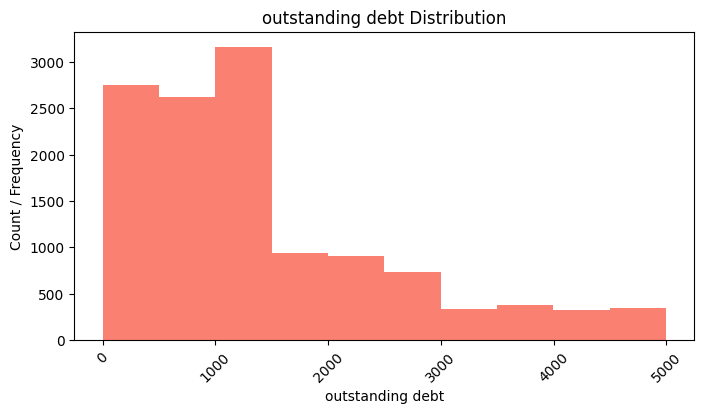

In [ ]:
# hist plot for outstanding debt distribution
plt.figure(figsize=(8, 4))
int_var2.plot(kind= 'hist', color = 'salmon')
plt.title('outstanding debt Distribution')
plt.xlabel('outstanding debt')
plt.ylabel('Count / Frequency')
plt.xticks(rotation = 45)
plt.show()  # right skew distribution

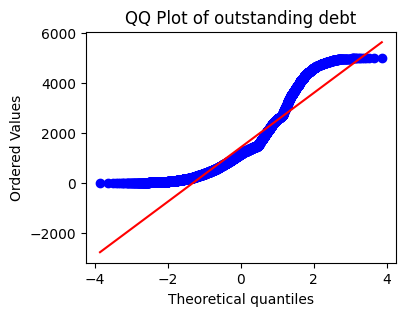

In [ ]:
### QQ plot for visualisation distribution
plt.figure(figsize=(4, 3))
stats.probplot(int_var2, dist="norm", plot=plt)
plt.title('QQ Plot of outstanding debt')
plt.show()

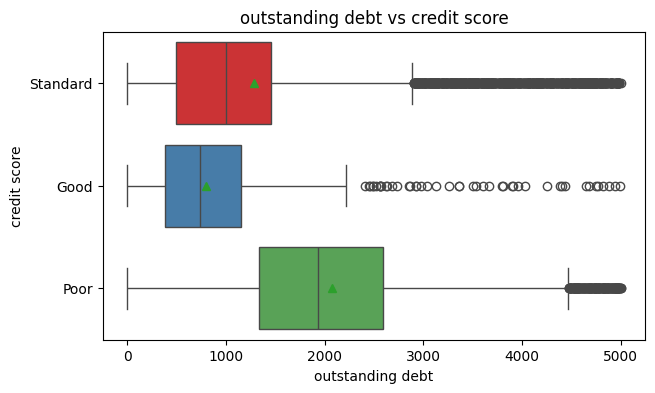

In [ ]:
# Box plot for each credit rating
plt.figure(figsize = (7, 4))
sns.boxplot(data = df, x = int_var2, y = target_name, palette='Set1', showmeans = True)
plt.title('outstanding debt vs credit score')
plt.xlabel('outstanding debt')
plt.ylabel('credit score')
plt.show()

# Customer with poor credit score have more outstanding debt.

In [ ]:
feature_2_insights = """
Overall, outstanding_dept also has the right skew distribution with the majority lying between 0 to approximately 1,400 dollars.
The box plot show that customer with poor status has an outstanding in mean and median which might directly influence the credit rating.
"""

In [ ]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='feature_2_insights', value=feature_2_insights)

### C.4 Explore Feature of Interest `\<monthly_emi_payment\>`


In [ ]:
int_var3 = df['monthly_emi_payment']

In [ ]:
# Descritive statistic
int_var3.describe().round(2)  # min value indicate incorrect value.

,monthly_emi_payment
count,12500.00
mean,88.19
std,83.26
min,-1.00
25%,25.56
50%,61.51
75%,131.39
max,357.41


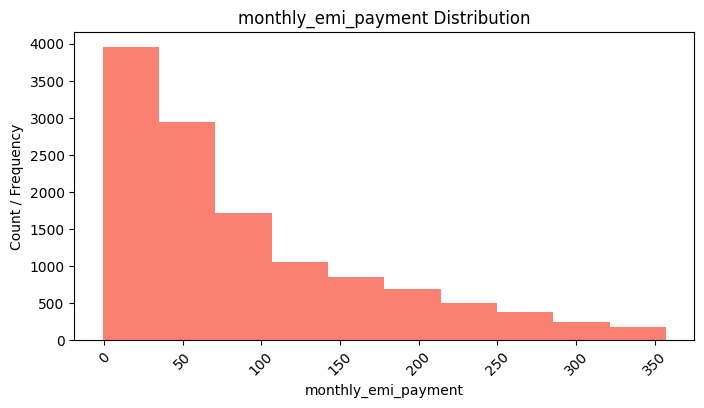

In [ ]:
# hist plot for income distribution
plt.figure(figsize=(8, 4))
int_var3.plot(kind= 'hist', color = 'salmon')
plt.title('monthly_emi_payment Distribution')
plt.xlabel('monthly_emi_payment')
plt.ylabel('Count / Frequency')
plt.xticks(rotation = 45)
plt.show()

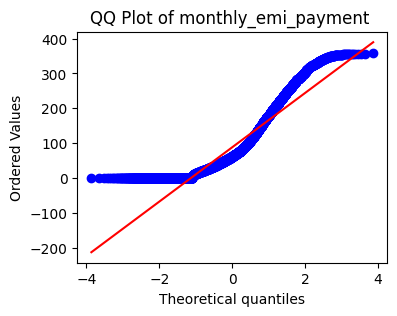

In [ ]:
### QQ plot for visualisation distribution
plt.figure(figsize=(4, 3))
stats.probplot(int_var3, dist="norm", plot=plt)
plt.title('QQ Plot of monthly_emi_payment ')
plt.show()

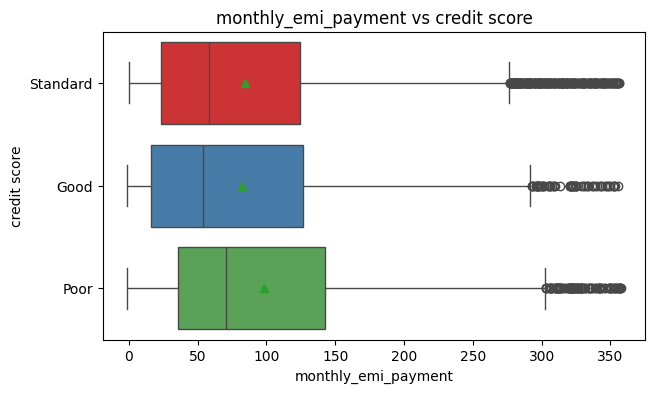

In [ ]:
# Box plot for each credit rating
plt.figure(figsize = (7, 4))
sns.boxplot(data = df, x = int_var3, y = target_name, palette='Set1', showmeans = True)
plt.title('monthly_emi_payment vs credit score')
plt.xlabel('monthly_emi_payment')
plt.ylabel('credit score')
plt.show()

In [ ]:
feature_3_insights = """
In summary, monthly_emi_payment have the right skew distribution which the mojority lie between 0 to 70 dollars. Min value = -1.00 indicating the incorrect value which require correcting.
From the box plot result, standard and good have a similar mean and median, but good has a slightly better (lower) mean, while poor still has the highest mean.
"""

In [ ]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='feature_3_insights', value=feature_3_insights)

### C.5 Explore Feature of Interest `\<count_delayed_payment\>`

In [ ]:
int_var4 = df['count_delayed_payment']

In [ ]:
# Descritive statistic
int_var4.describe().round(2)

,count_delayed_payment
count,12500.00
mean,13.34
std,6.27
min,0.00
25%,9.00
50%,14.00
75%,18.00
max,28.00


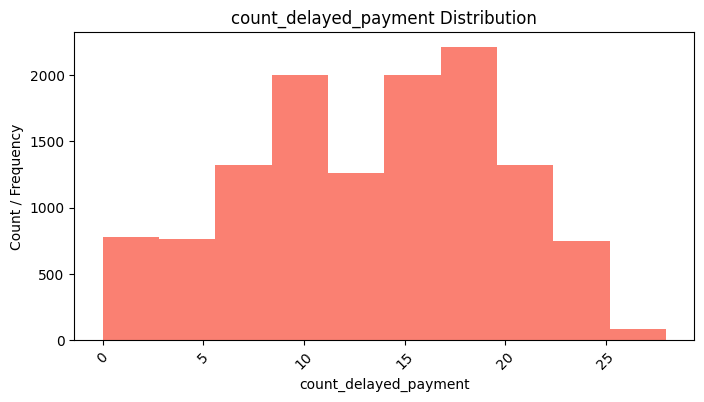

In [ ]:
# hist plot for income distribution
plt.figure(figsize=(8, 4))
int_var4.plot(kind= 'hist', color = 'salmon')
plt.title('count_delayed_payment Distribution')
plt.xlabel('count_delayed_payment')
plt.ylabel('Count / Frequency')
plt.xticks(rotation = 45)
plt.show()

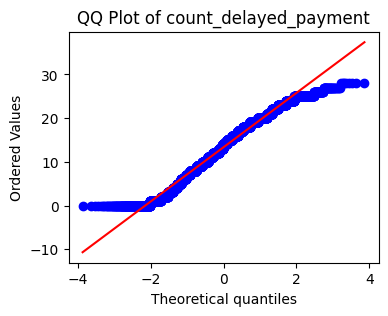

In [ ]:
### QQ plot for visualisation distribution
plt.figure(figsize=(4, 3))
stats.probplot(int_var4, dist="norm", plot=plt)
plt.title('QQ Plot of count_delayed_payment')
plt.show()

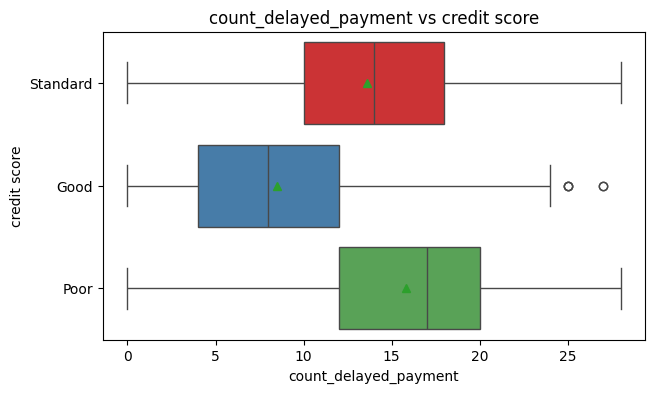

In [ ]:
# Box plot for each credit rating
plt.figure(figsize = (7, 4))
sns.boxplot(data = df, x = int_var4, y = target_name, palette='Set1', showmeans = True)
plt.title('count_delayed_payment vs credit score')
plt.xlabel('count_delayed_payment')
plt.ylabel('credit score')
plt.show()


In [ ]:
feature_4_insights = """
According to the distribution chart, count_delay_payment has a weird distribution with the majority lying in the middle.
From box plot, poor have the highest number followed by standard.
"""

In [ ]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='feature_4_insights', value=feature_4_insights)

### C.6 Explore Feature of Interest `\<loans_count\>`

In [ ]:
int_var5 = df['loans_count']

In [ ]:
# Descritive statistic
int_var5.describe().round(2)

,loans_count
count,12500.00
mean,3.53
std,2.45
min,0.00
25%,2.00
50%,3.00
75%,5.00
max,9.00


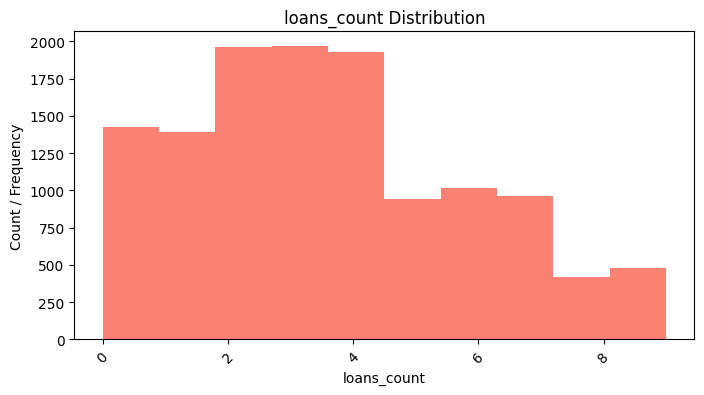

In [ ]:
# hist plot for income distribution
plt.figure(figsize=(8, 4))
int_var5.plot(kind= 'hist', color = 'salmon')
plt.title('loans_count Distribution')
plt.xlabel('loans_count')
plt.ylabel('Count / Frequency')
plt.xticks(rotation = 45)
plt.show()

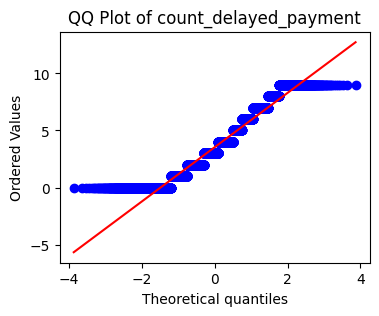

In [ ]:
### QQ plot for visualisation distribution
plt.figure(figsize=(4, 3))
stats.probplot(int_var5, dist="norm", plot=plt)
plt.title('QQ Plot of count_delayed_payment')
plt.show()

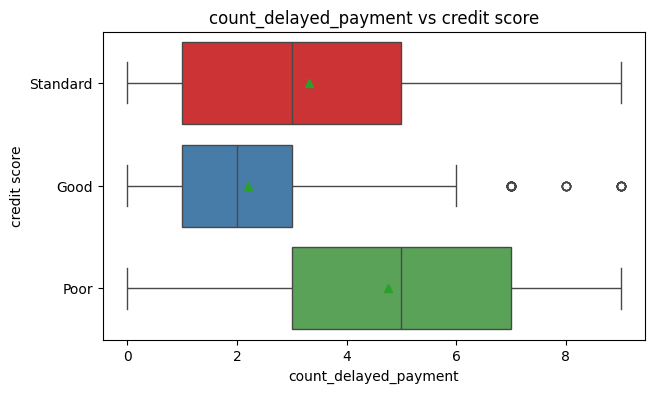

In [ ]:
# Box plot for each credit rating
plt.figure(figsize = (7, 4))
sns.boxplot(data = df, x = int_var5, y = target_name, palette='Set1', showmeans = True)
plt.title('count_delayed_payment vs credit score')
plt.xlabel('count_delayed_payment')
plt.ylabel('credit score')
plt.show()

In [ ]:
feature_5_insights = """
count_delayed_payment have right distribution which min = 0, max = 9 and mean = 3.53.
Box plot also show the similar pattern when we compare with the other interest variables which is poor status has a higher mean when the feature are directly affect the target variable.
"""

In [ ]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='feature_5_insights', value=feature_5_insights)